In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import os

In [2]:
# 1. DATA LOADING & PREPROCESSING FUNCTION

def load_and_preprocess_data(filepath, target_col):
    """Loads CSV and dynamically cleans the target variable."""
    df = pd.read_csv(filepath)
    
    # Clean the target column if it is text-based ('pass' / 'fail')
    if df[target_col].dtype == 'object':
        df[target_col] = df[target_col].str.strip().str.lower()
        # You can expand this dictionary for different datasets
        df[target_col] = df[target_col].map({'fail': 0, 'pass': 1})
        
    df = df.dropna() # Good practice: drop missing values
    return df

In [3]:
# 2. DYNAMIC EDA FUNCTION

def perform_eda(df, target_col):
    """Automatically generates EDA graphs regardless of how many columns you have."""
    print("--- Generating Exploratory Data Analysis (EDA) ---")
    
    # A. Target Distribution
    plt.figure(figsize=(6, 4))
    sns.countplot(x=target_col, data=df, palette='viridis')
    plt.title("Target Distribution (0=Fail, 1=Pass)")
    plt.show()

    # Get all numeric columns dynamically (ignoring target)
    numeric_cols = df.select_dtypes(include=['number']).columns.drop(target_col, errors='ignore')
    num_features = len(numeric_cols)
    
    # B. Histograms
    fig, axes = plt.subplots(1, num_features, figsize=(4 * num_features, 4))
    for i, col in enumerate(numeric_cols):
        ax = axes[i] if num_features > 1 else axes
        sns.histplot(df[col], kde=True, ax=ax, color='skyblue')
        ax.set_title(f"{col} Distribution")
    plt.tight_layout()
    plt.show()

    # C. Boxplots vs Target
    fig, axes = plt.subplots(1, num_features, figsize=(4 * num_features, 4))
    for i, col in enumerate(numeric_cols):
        ax = axes[i] if num_features > 1 else axes
        sns.boxplot(x=target_col, y=col, data=df, ax=ax, palette='Set2')
        ax.set_title(f"{col} vs {target_col}")
    plt.tight_layout()
    plt.show()

    # D. Correlation Heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap")
    plt.show()

In [4]:
# 3. MODEL TRAINING FUNCTION
# ==========================================
def train_and_evaluate_model(df, target_col):
    """Trains a Logistic Regression model using Best Practices (Scaling)."""
    X = df.drop(target_col, axis=1)
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Best Practice: Standardize features for Logistic Regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression()
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print("\n--- Model Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Save BOTH the model and the scaler
    joblib.dump(model, open("student_model.pkl", "wb"))
    joblib.dump(scaler, open("scaler.pkl", "wb"))
    print("\nModel and Scaler saved successfully.")
    
    return list(X.columns) # Return dynamic feature names for inference

In [5]:
# 4. PREDICTION FUNCTION
# ==========================================
def predict_new_student(feature_names):
    """Dynamically asks for user input based on the trained features."""
    print("\n--- Predict New Student ---")
    model = joblib.load("student_model.pkl")
    scaler = joblib.load("scaler.pkl")

    user_data = []
    for f in feature_names:
        val = float(input(f"Enter {f}: "))
        user_data.append(val)

    # Must scale the user input using the saved scaler!
    df_input = pd.DataFrame([user_data], columns=feature_names)
    scaled_input = scaler.transform(df_input)
    
    prediction = model.predict(scaled_input)[0]

    if prediction == 1:
        print("\n✅ Prediction: Student will PASS")
    else:
        print("\n❌ Prediction: Student will FAIL")

--- Generating Exploratory Data Analysis (EDA) ---


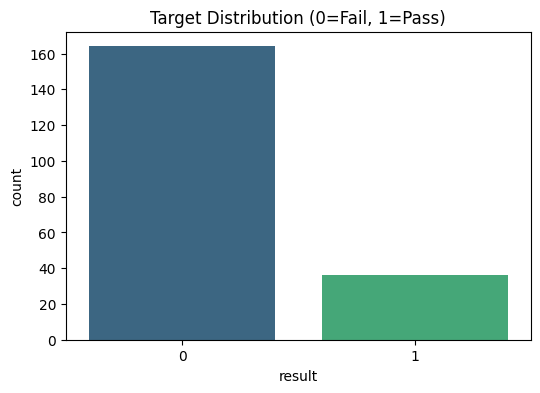

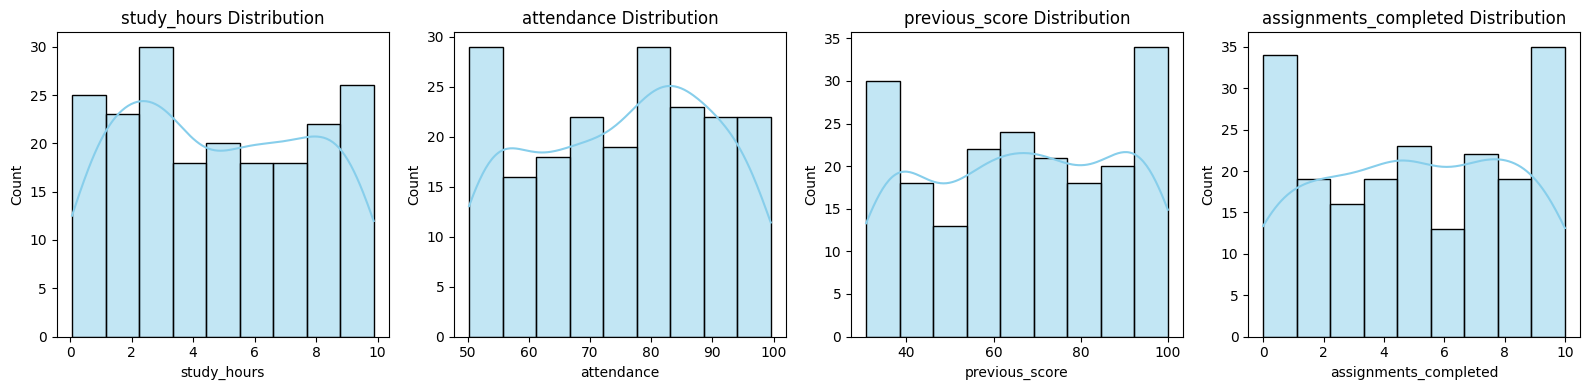

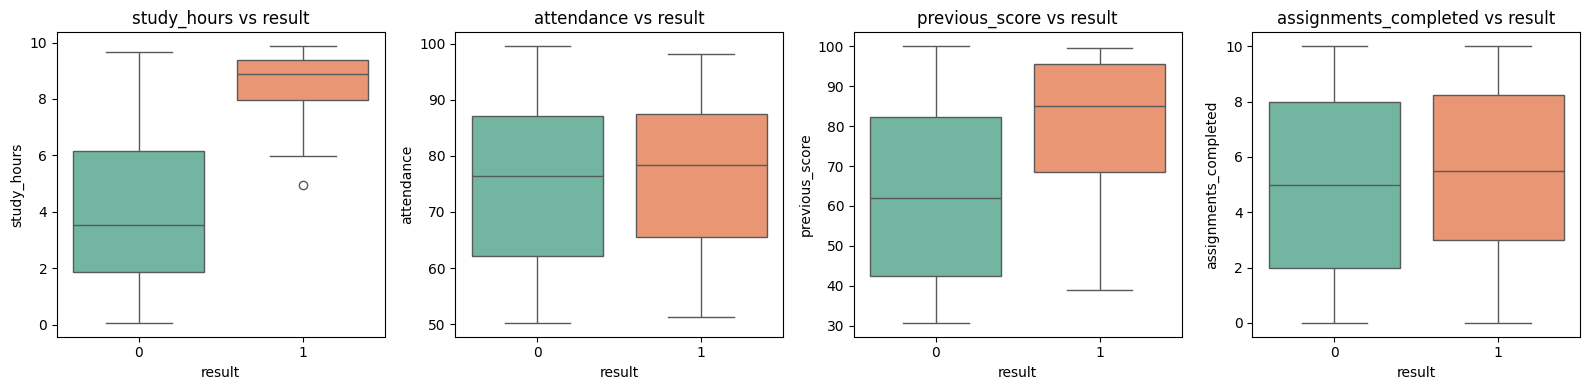

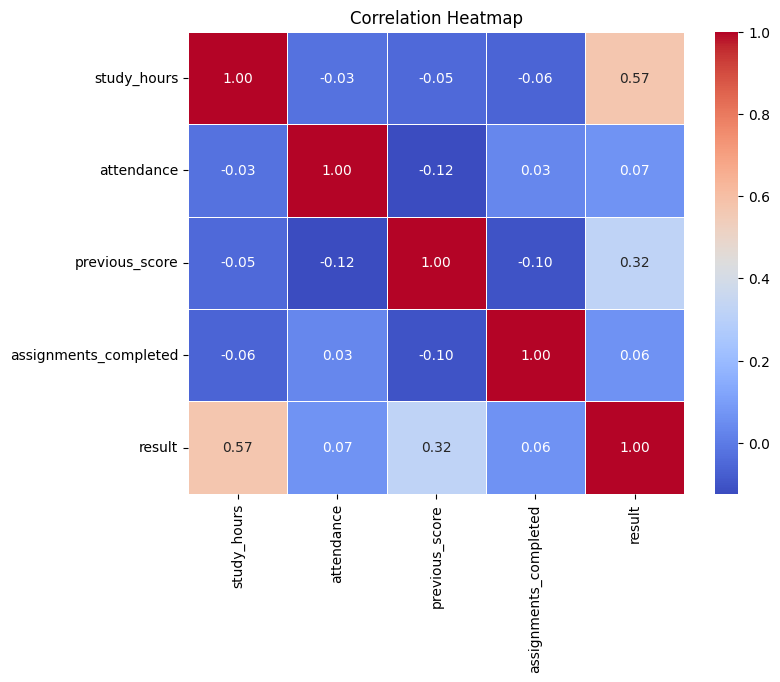


--- Model Evaluation ---
Accuracy: 100.00%

Confusion Matrix:
 [[32  0]
 [ 0  8]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       1.00      1.00      1.00         8

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


Model and Scaler saved successfully.


In [9]:
# MASTER EXECUTION PIPELINE
# ==========================================
if __name__ == "__main__":
    # 1. Set your dataset and target
    DATA_PATH = "student_performance_200.csv"
    TARGET = 'result'
    
    # 2. Run Pipeline
    df_clean = load_and_preprocess_data(DATA_PATH, TARGET)
    perform_eda(df_clean, TARGET)
    trained_features = train_and_evaluate_model(df_clean, TARGET)
    
    # 3. Test a new student
    # predict_new_student(trained_features)

In [10]:

def predict_exact_targets(feature_names):
    """
    Predicts result and calculates the EXACT numbers needed to pass.
    """
    print("\n" + "="*40)
    print("🎓 AI STUDENT SUCCESS PLANNER")
    print("="*40)
    
    # Load trained model and scaler
    try:
        model = joblib.load("student_model.pkl")
        scaler = joblib.load("scaler.pkl")
    except FileNotFoundError:
        print("Error: Model files not found. Please train the model first.")
        return

    # 1. Collect User Input
    user_data = []
    for f in feature_names:
        val = float(input(f"Enter {f}: "))
        user_data.append(val)

    # 2. Process Input
    df_input = pd.DataFrame([user_data], columns=feature_names)
    scaled_input = scaler.transform(df_input)
    
    # Predict Probability and Class
    pass_prob = model.predict_proba(scaled_input)[0][1] * 100
    prediction = model.predict(scaled_input)[0]

    # 3. Output Results
    if prediction == 1:
        print(f"\n✅ Prediction: PASS ({pass_prob:.1f}% Confidence)")
        print("Keep up the great work!")
        return

    print(f"\n❌ Prediction: FAIL (Chance of Passing: {pass_prob:.1f}%)")
    print("\n--- 🎯 EXACT TARGETS TO PASS ---")
    print("To instantly flip your prediction to PASS, achieve ONE of these goals:\n")
    
    # Define logical maximums so the loop doesn't run infinitely
    # If you add new columns, you can add their maximum possible value here!
    max_vals = {
        'study_hours': 24.0, 
        'attendance': 100.0, 
        'previous_score': 100.0, 
        'assignments_completed': 50.0
    }
    
    # GOAL SEEKING ALGORITHM
    for feature in feature_names:
        current_val = df_input[feature].iloc[0]
        temp_df = df_input.copy()
        
        # Use a small step for precision. If it's assignments, use whole numbers (1.0).
        step = 1.0 if 'assignment' in feature.lower() else 0.1
        
        # Get the max value for this feature, default to 1000 if not specified
        max_limit = max_vals.get(feature, 1000) 
        
        found = False
        
        # Keep incrementing the feature until the model predicts PASS
        while temp_df[feature].iloc[0] <= max_limit:
            temp_df[feature] += step
            
            # Re-scale and re-predict
            sim_pred = model.predict(scaler.transform(temp_df))[0]
            
            if sim_pred == 1: # WE FOUND THE PASSING THRESHOLD!
                target_val = temp_df[feature].iloc[0]
                diff = target_val - current_val
                print(f"• {feature}: Increase to {target_val:.1f} (+{diff:.1f} needed)")
                found = True
                break # Move on to the next feature
                
        if not found:
             print(f"• {feature}: Maxing this out alone is not enough to pass.")


# ==========================================
# TEST RUN 
# ==========================================
if __name__ == "__main__":
    trained_features = ['study_hours', 'attendance', 'previous_score', 'assignments_completed']
    predict_exact_targets(trained_features)


🎓 AI STUDENT SUCCESS PLANNER

✅ Prediction: PASS (96.0% Confidence)
Keep up the great work!


In [ ]:

# # 1. Load dataset
# df = pd.read_csv("student_performance_200.csv")

# # 2. Clean target column (VERY IMPORTANT)
# df['result'] = df['result'].str.strip().str.lower().map({'fail': 0, 'pass': 1})

# # 3. Features & target
# X = df.drop('result', axis=1)
# y = df['result']

# # 4. Train-test split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # 5. Train model (classification)
# model = LogisticRegression()
# model.fit(X_train, y_train)

# # 6. Create folder if not exists
# if not os.path.exists('model'):
#     os.makedirs('model')

# # 7. Save model
# joblib.dump(model, 'model/student_model.pkl')

# print("✅ Student model created and saved successfully!")

In [11]:
# df.head()

In [12]:
import os
print(os.getcwd())  # Shows the folder where Python is currently running


/content


In [13]:
import os
print(os.listdir('/content'))

['.config', 'student_model.pkl', 'scaler.pkl', 'student_performance_200.csv', 'sample_data']
